In [1]:
print("Pene de Lur")
print("Nigga")
print("Hola Luristán")
print("iñigo therian")

Pene de Lur
Nigga
Hola Luristán
iñigo therian


In [3]:
### IMPORTS ###
import pandas as pd
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import optuna
from optuna.pruners import MedianPruner
import xgboost as xgb
from sklearn.ensemble import (
    VotingClassifier, BaggingClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score, matthews_corrcoef
)
import pandas as pd
import warnings

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import missingno as msno
import seaborn as sns
from sklearn.impute import SimpleImputer, MissingIndicator

warnings.filterwarnings('ignore')

# ── GPU DETECTION ─────────────────────────────────────────────────────────────
# We use torch only for detection — it's the most reliable way to check CUDA
# availability without depending on XGBoost internals.
# If torch is not installed, we fall back to CPU silently.
try:
    import torch
    USE_GPU = torch.cuda.is_available()
except ImportError:
    USE_GPU = False

if USE_GPU:
    gpu_name = torch.cuda.get_device_name(0)
    print(f"GPU detected: {gpu_name} — XGBoost will use CUDA.")
else:
    print("No GPU detected — running on CPU. All models work normally.")

# Trials per model: increase if you have GPU to take advantage of faster XGBoost tuning.
# Anyone running on CPU can lower this (e.g. 10–15) to reduce waiting time.
N_TRIALS_PER_MODEL = 50 if USE_GPU else 20

# ─────────────────────────────────────────────────────────────────────────────

c:\Users\Jon Uni\miniconda3\envs\advancedML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


No GPU detected — running on CPU. All models work normally.


DATA PROCESSING

In [4]:
### DATASET LOADING ###

#Lo antiguo de Jon
#gauth = GoogleAuth()
#gauth.LocalWebserverAuth()
#drive = GoogleDrive(gauth)

# Google Drive ID for public sharing of the dataset
#file_id = "1aGGJNl1VtET_6HqQh81ouSKqe6-lN-OG"
#file = drive.CreateFile({"id": file_id})
#file.GetContentFile("ai_tools.csv")

# Reading the csv and loading it into a pandas dataframe.
#df = pd.read_csv("ai_tools.csv")
#df.head()

url = "https://raw.githubusercontent.com/GafillaAbrahamer/ClassificationProject/refs/heads/main/AI_Landscape_19k_Tools_2026.csv"
df = pd.read_csv(url)
df.head()

# The target is already a categorical multiclass column — no transformation needed.
# Classes: "Free", "Freemium", "Subscription", "Pay-as-you-go", "Open Source", "Usage-Based"

# We remove the target from the features to avoid data leakage.
X = df.drop(["Pricing_Model"], axis=1)

# We only keep the label.
y = df[["Pricing_Model"]]

print(X)
print(y)

               AI_Name     Developer  Release_Year  \
0             Scrip Ai       Scripai          2024   
1             Quickads      Quickads          2025   
2           Wonderchat    Wonderchat          2024   
3         Creatosaurus  Creatosaurus          2023   
4                Blobr         Blobr          2025   
...                ...           ...           ...   
19324         Emozi Ai         Emozi          2025   
19325        Myresumai     Myresumai          2022   
19326  Code Screenshot            Cs          2024   
19327      Ho Ho Hello     Hohohello          2022   
19328             Puti          Puti          2024   

                 Intelligence_Type Primary_Domain  \
0                 Generative Video          Video   
1      Computer Vision / Diffusion   Image/Design   
2         Multimodal Generative AI  General/Other   
3                 Autonomous Agent     Automation   
4                 Autonomous Agent     Automation   
...                            ..

In [5]:
### MISSING DATA ANALYSIS ###

# Total missing values per column
print("Missing values per column:")
print(df.isnull().sum())

# Percentage of missing values per column
print("\nMissing values (%):")
print((df.isnull().sum() / len(df) * 100).round(2))

# Quick summary: any missing at all?
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing values per column:
AI_Name                 0
Developer               0
Release_Year            0
Intelligence_Type       0
Primary_Domain          0
Key_Functionality       0
Pricing_Model           0
API_Availability        0
Context_Window       3877
Accessibility           0
Website_URL             0
Popularity_Votes        0
dtype: int64

Missing values (%):
AI_Name               0.00
Developer             0.00
Release_Year          0.00
Intelligence_Type     0.00
Primary_Domain        0.00
Key_Functionality     0.00
Pricing_Model         0.00
API_Availability      0.00
Context_Window       20.06
Accessibility         0.00
Website_URL           0.00
Popularity_Votes      0.00
dtype: float64

Total missing values in dataset: 3877


In [6]:
### TRANSFORMATION PIPELINE ###
# We drop non-informative columns
cols_to_drop = ['AI_Name', 'Developer', 'Website_URL', 'Key_Functionality']
X = df.drop(columns=cols_to_drop + ['Pricing_Model'])
y = df['Pricing_Model']
X['Context_Window'] = X['Context_Window'].fillna('N/A')

# Train / Validation / Test split (80-10-10)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train size:      {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size:       {X_test.shape[0]}")

# We define column groups for encoding
ordinal_cols = ['Context_Window']
ordinal_categories = [['N/A', '8k', '32k', '128k', '1M']]  # explicit order

onehot_cols = ['Intelligence_Type', 'Primary_Domain', 'API_Availability', 'Accessibility']

numerical_cols = ['Release_Year', 'Popularity_Votes']

# we build the ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
    ('scaler', StandardScaler(), numerical_cols),
])

# we fit ONLY on train, then transform each split
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

# Optional: recover a readable DataFrame
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(onehot_cols)
feature_names = ordinal_cols + list(onehot_feature_names) + numerical_cols

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_val_processed   = pd.DataFrame(X_val_processed,   columns=feature_names)
X_test_processed  = pd.DataFrame(X_test_processed,  columns=feature_names)

print(X_train_processed.head())
print(f"\nFinal shape — Train: {X_train_processed.shape}, Val: {X_val_processed.shape}, Test: {X_test_processed.shape}")

Train size:      15463
Validation size: 1933
Test size:       1933
   Context_Window  Intelligence_Type_Autonomous Agent  \
0             3.0                                 0.0   
1             0.0                                 1.0   
2             3.0                                 0.0   
3             3.0                                 0.0   
4             4.0                                 0.0   

   Intelligence_Type_Code Intelligence  \
0                                  0.0   
1                                  0.0   
2                                  0.0   
3                                  0.0   
4                                  0.0   

   Intelligence_Type_Computer Vision / Diffusion  \
0                                            0.0   
1                                            0.0   
2                                            0.0   
3                                            1.0   
4                                            0.0   

   Intelligence_Type_Gen

IMBALANCE ANALYSIS AND MITIGATION

Class distribution analysis

In [7]:
# --- Class distribution analysis ---
# From 3.1: same pattern as df['annotation'].value_counts()

class_counts = y.value_counts()
print(f"The class distribution is:\n{class_counts}")

class_percentages = (class_counts / class_counts.sum()) * 100
print(f"\nThe class percentage distribution is:\n{class_percentages.round(2)}")

The class distribution is:
Pricing_Model
Freemium         7665
Free             3926
Subscription     3876
Pay-as-you-go    1960
Open Source      1902
Name: count, dtype: int64

The class percentage distribution is:
Pricing_Model
Freemium         39.66
Free             20.31
Subscription     20.05
Pay-as-you-go    10.14
Open Source       9.84
Name: count, dtype: float64


Bar chart

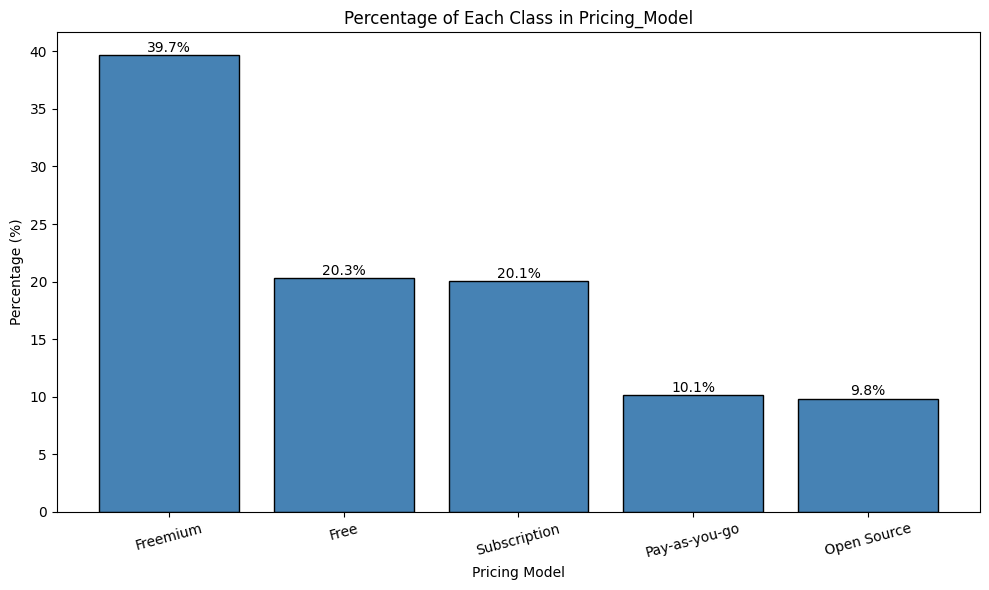

In [8]:
# --- Bar chart of class distribution ---
# From 3.1: adapted from the pie chart cell

plt.figure(figsize=(10, 6))
plt.bar(class_percentages.index, class_percentages.values, color='steelblue', edgecolor='black')
plt.title('Percentage of Each Class in Pricing_Model')
plt.xlabel('Pricing Model')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
for i, v in enumerate(class_percentages.values):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

class_distribution helper function

In [9]:
# --- Helper function to print class distribution ---
# From 3.1: class_distribution() function, copied exactly

def class_distribution(y):
    unique, counts = np.unique(y, return_counts=True)
    total_samples = len(y)
    percentages = (counts / total_samples) * 100
    distribution = dict(zip(unique, zip(counts, percentages)))

    for class_label, (count, percentage) in distribution.items():
        print(f'Class {class_label}: {count} samples, {percentage:.2f}% of the dataset')

run_pipeline helper function

In [10]:
# --- Helper function to run and evaluate a pipeline ---
# From 3.2: run_pipeline() function, copied exactly, 
# adapted to use macro averaging since this is multiclass

def run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name=None):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print("Experiment name: " + exp_name)
    print("Accuracy:  ", round(accuracy_score(y_test, y_pred), 4))
    print("Precision: ", round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4), "(macro)")
    print("Recall:    ", round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4), "(macro)")
    print("F1:        ", round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4), "(macro)")
    print(f"Predicted class distribution:\n{pd.Series(y_pred).value_counts()}")
    print()

Baseline: no mitigation

In [11]:
# --- Baseline: no imbalance mitigation ---
# From 3.2: same structure as run_pipeline experiments

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print("=" * 50)
print("BASELINE — No mitigation")
print("=" * 50)
class_distribution(y_train_encoded)   # OJO CON Y_TRAIN QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

pipe_baseline = LogisticRegression(max_iter=1000, random_state=42)
run_pipeline(pipe_baseline, X_train_processed, X_test_processed,
             y_train_encoded, y_test_encoded, "Baseline (no mitigation)")       # OJO CON Y_TRAIN E Y_TEST QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

BASELINE — No mitigation
Class 0: 3141 samples, 20.31% of the dataset
Class 1: 6132 samples, 39.66% of the dataset
Class 2: 1521 samples, 9.84% of the dataset
Class 3: 1568 samples, 10.14% of the dataset
Class 4: 3101 samples, 20.05% of the dataset
Experiment name: Baseline (no mitigation)
Accuracy:   0.3963
Precision:  0.0793 (macro)
Recall:     0.2 (macro)
F1:         0.1135 (macro)
Predicted class distribution:
1    1933
Name: count, dtype: int64



class_weight='balanced'

In [12]:
# --- class_weight='balanced' ---
# From 3.1: LogisticRegression(class_weight='balanced') pattern

print("=" * 50)
print("CLASS WEIGHT — balanced")
print("=" * 50)

pipe_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
run_pipeline(pipe_balanced, X_train_processed, X_test_processed,
             y_train_encoded, y_test_encoded, "class_weight='balanced'")       # OJO CON Y_TRAIN QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

CLASS WEIGHT — balanced
Experiment name: class_weight='balanced'
Accuracy:   0.1733
Precision:  0.1905 (macro)
Recall:     0.1859 (macro)
F1:         0.1665 (macro)
Predicted class distribution:
2    508
3    408
0    380
4    345
1    292
Name: count, dtype: int64



 Oversampling techniques compared

In [13]:
# --- Oversampling and combined techniques compared ---
# From 3.2: Exercise 1 run_pipeline loop pattern, using ImbPipeline

print("=" * 50)
print("RESAMPLING TECHNIQUES COMPARISON")
print("=" * 50)

samplers = [
    (RandomOverSampler(random_state=42),  "RandomOverSampler"),
    (SMOTE(random_state=42),              "SMOTE"),
    (ADASYN(random_state=42),             "ADASYN"),
    (RandomUnderSampler(random_state=42), "RandomUnderSampler"),
    (SMOTEENN(random_state=42),           "SMOTEENN"),
    (SMOTETomek(random_state=42),         "SMOTETomek"),
]

for sampler, name in samplers:
    pipe = ImbPipeline([
        ('resample',    sampler),
        ('classifier',  LogisticRegression(max_iter=1000, random_state=42)),
    ])
    run_pipeline(pipe, X_train_processed, X_test_processed,
                 y_train_encoded, y_test_encoded, name)      # OJO CON Y_TRAIN E Y_TEST QUE EN REALIDAD ES Y_TRAIN ENCODED PERO ESTA MAS ABAJO, LO DEJO ASI PARA NO TENER QUE REESCRIBIRLO TODO AHORA, PERO HAY QUE CAMBIARLO DESPUES

RESAMPLING TECHNIQUES COMPARISON
Experiment name: RandomOverSampler
Accuracy:   0.1728
Precision:  0.2036 (macro)
Recall:     0.1999 (macro)
F1:         0.1706 (macro)
Predicted class distribution:
2    513
0    467
3    409
4    356
1    188
Name: count, dtype: int64

Experiment name: SMOTE
Accuracy:   0.1516
Precision:  0.185 (macro)
Recall:     0.1822 (macro)
F1:         0.1489 (macro)
Predicted class distribution:
2    652
0    413
3    366
4    335
1    167
Name: count, dtype: int64

Experiment name: ADASYN
Accuracy:   0.1837
Precision:  0.2042 (macro)
Recall:     0.1998 (macro)
F1:         0.174 (macro)
Predicted class distribution:
0    540
2    504
3    412
1    258
4    219
Name: count, dtype: int64

Experiment name: RandomUnderSampler
Accuracy:   0.2157
Precision:  0.1948 (macro)
Recall:     0.1965 (macro)
F1:         0.1879 (macro)
Predicted class distribution:
1    529
2    405
0    403
4    307
3    289
Name: count, dtype: int64

Experiment name: SMOTEENN
Accuracy:   0.107

Class distribution after best resampler

In [14]:
# --- Inspect class distribution after resampling ---
# From 3.1: class_distribution() usage after fit_resample

print("Class distribution BEFORE resampling:")
class_distribution(y_train_encoded)      

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_processed, y_train_encoded)     
print("\nClass distribution AFTER SMOTE resampling:")
class_distribution(y_resampled)

Class distribution BEFORE resampling:
Class 0: 3141 samples, 20.31% of the dataset
Class 1: 6132 samples, 39.66% of the dataset
Class 2: 1521 samples, 9.84% of the dataset
Class 3: 1568 samples, 10.14% of the dataset
Class 4: 3101 samples, 20.05% of the dataset

Class distribution AFTER SMOTE resampling:
Class 0: 6132 samples, 20.00% of the dataset
Class 1: 6132 samples, 20.00% of the dataset
Class 2: 6132 samples, 20.00% of the dataset
Class 3: 6132 samples, 20.00% of the dataset
Class 4: 6132 samples, 20.00% of the dataset


PARTE DE 3.3 (3.4 NO NOS SIRVE)

Missingness analysis

In [15]:
# From 3.3: same pattern as df.isnull().sum() block
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

print("\nMissing values (%):")
print((df.isnull().sum() / len(df) * 100).round(2)[df.isnull().sum() > 0])

print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing values per column:
Context_Window    3877
dtype: int64

Missing values (%):
Context_Window    20.06
dtype: float64

Total missing values in dataset: 3877


Missingno matrix and heatmap

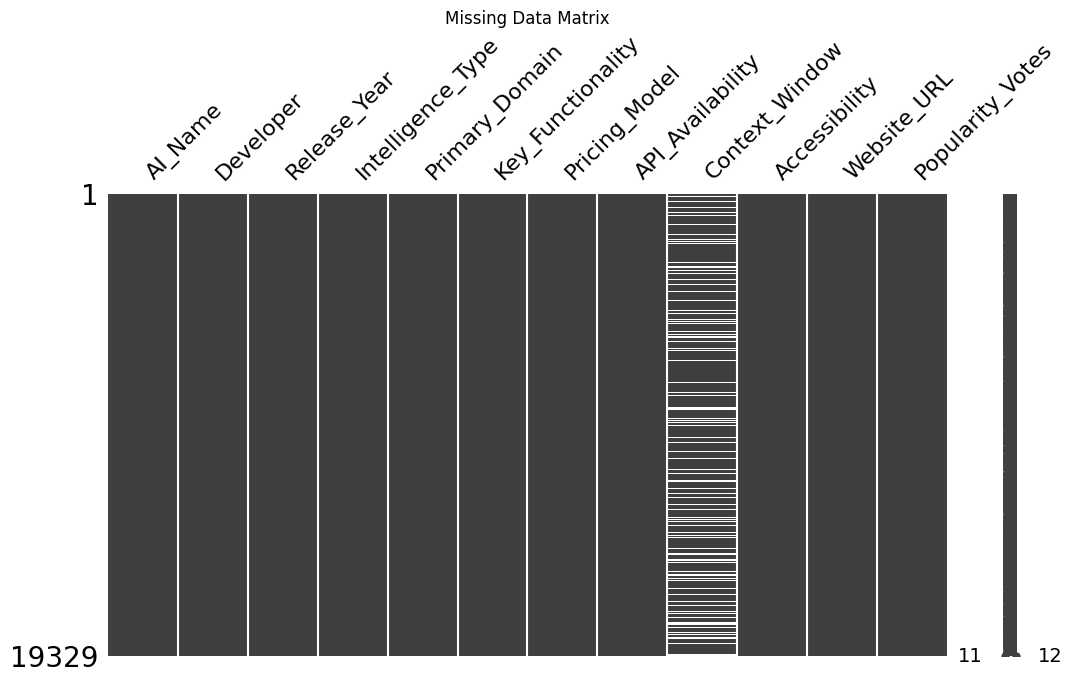

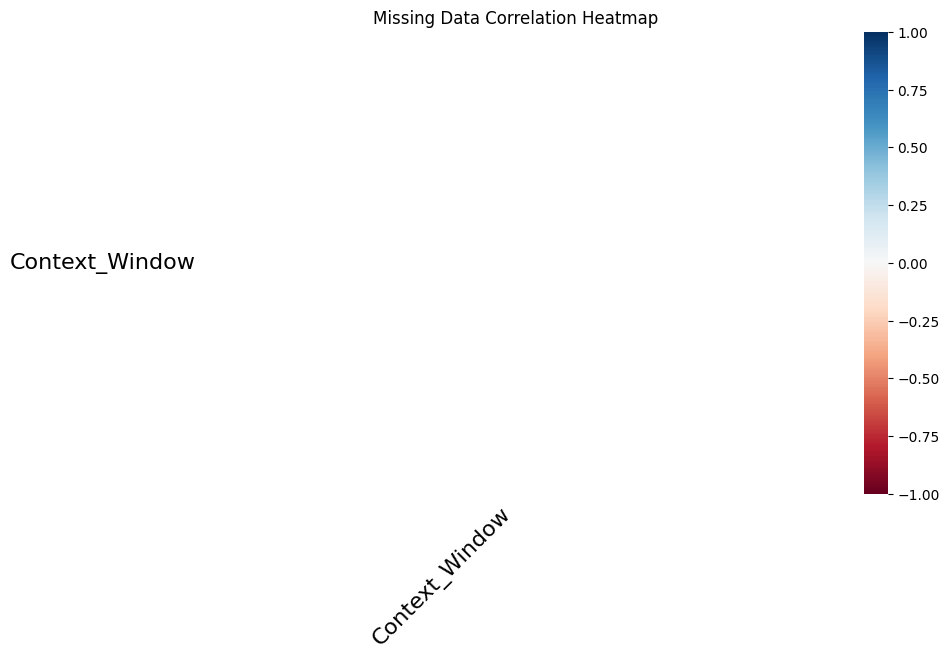

In [16]:
# From 3.3 Exercise 1: missingno matrix and heatmap, copied exactly

msno.matrix(df, figsize=(12, 6))
plt.title('Missing Data Matrix')
plt.show()

msno.heatmap(df, figsize=(10, 6))
plt.title('Missing Data Correlation Heatmap')
plt.show()

Distribution of Context_Window before imputation

In [17]:
# From 3.3: compare_distributions helper, copied exactly

def compare_distributions(original, imputed, imputing_technique, feature):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(original[feature].dropna(), kde=False, color="blue", label="Original")
    plt.title('Original {} Distribution'.format(feature))
    plt.legend()

    plt.subplot(1, 2, 2)
    sns.histplot(imputed[feature].dropna(), kde=False, color="green",
                 label="{} Imputed".format(imputing_technique))
    plt.title('{} Imputed {} Distribution'.format(imputing_technique, feature))
    plt.legend()

    plt.tight_layout()
    plt.show()

Mode imputation (most_frequent)

Most frequent value used for imputation: 128k


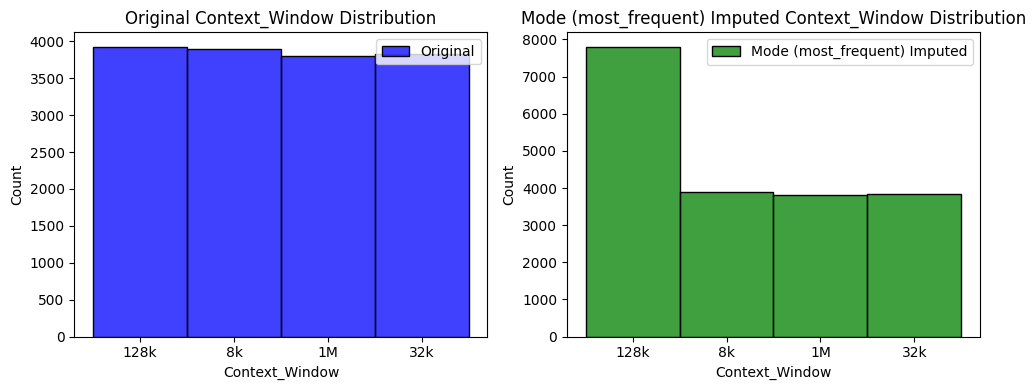


Context_Window distribution after imputation:
Context_Window
128k    7802
8k      3895
32k     3833
1M      3799
Name: count, dtype: int64


In [18]:
# From 3.3 Exercise 2: SimpleImputer with most_frequent strategy
# Context_Window is categorical so mode (most_frequent) is the correct choice,
# same as the 'embarked' imputation in the Titanic example

df_copy = df.copy()

imputer_mode = SimpleImputer(strategy='most_frequent')
df_copy['Context_Window'] = imputer_mode.fit_transform(
    df_copy[['Context_Window']]
).ravel()

print(f"Most frequent value used for imputation: {imputer_mode.statistics_[0]}")
compare_distributions(df, df_copy, "Mode (most_frequent)", "Context_Window")

print("\nContext_Window distribution after imputation:")
print(df_copy['Context_Window'].value_counts())

Missingness indicator

In [19]:
# From 3.3 Exercise 2b: add_indicator=True to track which rows were imputed
# Same pattern as the age_missing indicator in the Titanic example

imputer_with_indicator = SimpleImputer(strategy='most_frequent', add_indicator=True)
imputed_context = imputer_with_indicator.fit_transform(df[['Context_Window']])

df_copy['Context_Window'] = imputed_context[:, 0]
df_copy['Context_Window_missing'] = imputed_context[:, 1]

print("Missingness indicator added — first few rows:")
print(df_copy[['Context_Window', 'Context_Window_missing']].head(10))
print(f"\nRows that were imputed: {int(df_copy['Context_Window_missing'].sum())}")

Missingness indicator added — first few rows:
  Context_Window Context_Window_missing
0           128k                  False
1             8k                  False
2             8k                  False
3             8k                  False
4             8k                  False
5             1M                  False
6           128k                  False
7             1M                  False
8           128k                   True
9           128k                   True

Rows that were imputed: 3877


MODEL COMPARISON AND HYPERPARAMETER TUNING

In [ ]:
### POINT 3: MODEL COMPARISON + HYPERPARAMETER TUNING WITH OPTUNA ###

# le, y_train_encoded, y_test_encoded, X_resampled, y_resampled
# are all defined in Point 2 — no need to redefine them here.

# ── OBJECTIVE FUNCTIONS — ONE PER MODEL ───────────────────────────────────────
# Using a separate study per model guarantees that each model gets exactly
# N_TRIALS_PER_MODEL trials, avoiding the unequal distribution that happens
# when Optuna decides how to allocate trials in a single joint study.
# All objectives use X_resampled and y_resampled (SMOTE-balanced train set).

def _xgb_device_kwargs():
    """Returns device-specific kwargs for XGBClassifier."""
    if USE_GPU:
        return {"device": "cuda", "tree_method": "hist"}
    return {}   # CPU default — XGBoost will use its own threading

def objective_votinghard(trial):
    clf = VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('rf', RandomForestClassifier(
                n_estimators=trial.suggest_int("rf_n_estimators", 50, 200),
                random_state=42
            )),
            ('svc', SVC(random_state=42))
        ],
        voting='hard'
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=-1).mean()

def objective_votingsoft(trial):
    clf = VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('rf', RandomForestClassifier(
                n_estimators=trial.suggest_int("rf_n_estimators", 50, 200),
                random_state=42
            )),
            # probability=True is required for soft voting — SVC does not
            # output probabilities by default, but soft voting needs them
            # to average class probabilities across estimators.
            ('svc', SVC(probability=True, random_state=42))
        ],
        voting='soft'
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=-1).mean()

def objective_bagging(trial):
    clf = BaggingClassifier(
        n_estimators=trial.suggest_int("n_estimators", 10, 200),
        max_samples=trial.suggest_float("max_samples", 0.5, 1.0),
        max_features=trial.suggest_float("max_features", 0.5, 1.0),
        random_state=42
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=-1).mean()

def objective_adaboost(trial):
    clf = AdaBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 2.0, log=True),
        random_state=42
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=-1).mean()

def objective_gradientboosting(trial):
    clf = GradientBoostingClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        random_state=42
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=-1).mean()

def objective_xgboost(trial):
    clf = xgb.XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        random_state=42,
        # eval_metric avoids a deprecation warning in multiclass problems.
        # verbosity=0 suppresses XGBoost's internal logs during tuning.
        eval_metric='mlogloss',
        verbosity=0
        **_xgb_device_kwargs()
    )
    _njobs = 1 if USE_GPU else -1
    return cross_val_score(clf, X_resampled, y_resampled, cv=3,
                           scoring='accuracy', n_jobs=_njobs).mean()

def objective_randomforest(trial):
    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 2, 20),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        random_state=42
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=-1).mean()

def objective_stacking(trial):
    clf = StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('svc', SVC(probability=True, random_state=42))
        ],
        final_estimator=LogisticRegression(
            C=trial.suggest_float("C", 1e-3, 10.0, log=True),
            max_iter=1000,
            random_state=42
        ),
        cv=3
    )
    return cross_val_score(clf, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=-1).mean()


# ── RUN ONE STUDY PER MODEL ───────────────────────────────────────────────────

optuna.logging.set_verbosity(optuna.logging.WARNING)

model_objectives = {
    "VotingHard":       objective_votinghard,
    "VotingSoft":       objective_votingsoft,
    "Bagging":          objective_bagging,
    "AdaBoost":         objective_adaboost,
    "GradientBoosting": objective_gradientboosting,
    "XGBoost":          objective_xgboost,
    "RandomForest":     objective_randomforest,
    "Stacking":         objective_stacking,
}

# We store each study so we can retrieve best params later
studies = {}
for name, objective_fn in model_objectives.items():
    print(f"Optimizing {name}...")
    study = optuna.create_study(direction="maximize", pruner=MedianPruner())
    study.optimize(objective_fn, n_trials=N_TRIALS_PER_MODEL)
    studies[name] = study
    print(f"  Best CV Accuracy: {study.best_value:.4f}  |  Best params: {study.best_params}")


# ── HELPER: build a model from its best params ────────────────────────────────

def build_model(name, params):
    """Reconstruct a model using the best params found by its Optuna study."""

    if name == "VotingHard":
        return VotingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(n_estimators=params["rf_n_estimators"], random_state=42)),
                ('svc', SVC(random_state=42))
            ],
            voting='hard'
        )
    elif name == "VotingSoft":
        return VotingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(n_estimators=params["rf_n_estimators"], random_state=42)),
                ('svc', SVC(probability=True, random_state=42))
            ],
            voting='soft'
        )
    elif name == "Bagging":
        return BaggingClassifier(
            n_estimators=params["n_estimators"],
            max_samples=params["max_samples"],
            max_features=params["max_features"],
            random_state=42
        )
    elif name == "AdaBoost":
        return AdaBoostClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            random_state=42
        )
    elif name == "GradientBoosting":
        return GradientBoostingClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            subsample=params["subsample"],
            random_state=42
        )
    elif name == "XGBoost":
        return xgb.XGBClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            subsample=params["subsample"],
            random_state=42,
            eval_metric='mlogloss',
            verbosity=0
            **_xgb_device_kwargs()
        )
    elif name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            max_features=params["max_features"],
            min_samples_split=params["min_samples_split"],
            random_state=42
        )
    else:  # Stacking
        return StackingClassifier(
            estimators=[
                ('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
                ('svc', SVC(probability=True, random_state=42))
            ],
            final_estimator=LogisticRegression(
                C=params["C"],
                max_iter=1000,
                random_state=42
            ),
            cv=3
        )


# ── FULL EVALUATION OF ALL MODELS ON TEST SET ─────────────────────────────────
# We retrain every model with its best hyperparameters on X_resampled/y_resampled
# (SMOTE-balanced train set) and evaluate on X_test_processed/y_test_encoded
# (original unbalanced test set — test must never be resampled).
# We use macro averaging — it treats all classes equally, which is especially
# informative in the presence of class imbalance.

print()
print("=" * 60)
print("FULL EVALUATION ON TEST SET — ALL MODELS")
print("=" * 60)

comparison_rows = []

for name, study in studies.items():
    best_params = study.best_params
    model = build_model(name, best_params)

    # Train on SMOTE-balanced data, evaluate on original unbalanced test set
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test_processed)

    acc  = accuracy_score(y_test_encoded, y_pred)
    prec = precision_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    mcc  = matthews_corrcoef(y_test_encoded, y_pred)

    comparison_rows.append({
        "Model":      name,
        "Accuracy":   round(acc,  4),
        "Precision":  round(prec, 4),
        "Recall":     round(rec,  4),
        "F1 (macro)": round(f1,   4),
        "MCC":        round(mcc,  4),
    })

    print(f"\n{'─'*40}")
    print(f"Model: {name}")
    print(f"  Best params:  {best_params}")
    print(f"  Accuracy:     {acc:.4f}")
    print(f"  Precision:    {prec:.4f}  (macro)")
    print(f"  Recall:       {rec:.4f}  (macro)")
    print(f"  F1 Score:     {f1:.4f}  (macro)")
    print(f"  MCC:          {mcc:.4f}")
    print()
    # Per-class breakdown — target_names restores original string labels
    print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))


# ── COMPARISON TABLE ──────────────────────────────────────────────────────────
# Summary table sorted by F1 score so it is easy to spot the best model overall.

print()
print("=" * 60)
print("COMPARISON TABLE (sorted by F1 macro)")
print("=" * 60)

df_results = pd.DataFrame(comparison_rows).sort_values("F1 (macro)", ascending=False)
df_results = df_results.reset_index(drop=True)
df_results.index += 1  # Start ranking from 1
print(df_results.to_string())

print()
best_row = df_results.iloc[0]
print(f"Best model overall: {best_row['Model']}  —  F1: {best_row['F1 (macro)']:.4f}  |  Accuracy: {best_row['Accuracy']:.4f}  |  MCC: {best_row['MCC']:.4f}")